In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
os.chdir('../')
import warnings
import scanpy as sc
import pandas as pd
import numpy as np

from matplotlib import pyplot as plt

In [2]:
# the data path
main_dir = '/home/wergillius/Project/diffuse_differentiate/'
data_dir = '/home/wergillius/Project/diffuse_differentiate/data/Collide-seq'

## read processed data

In [3]:
# knn and umap is computed here
adata_proc = sc.read_h5ad(f"{data_dir}/adata_proc.h5ad")

/home/wergillius/.conda/envs/GenDiff/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


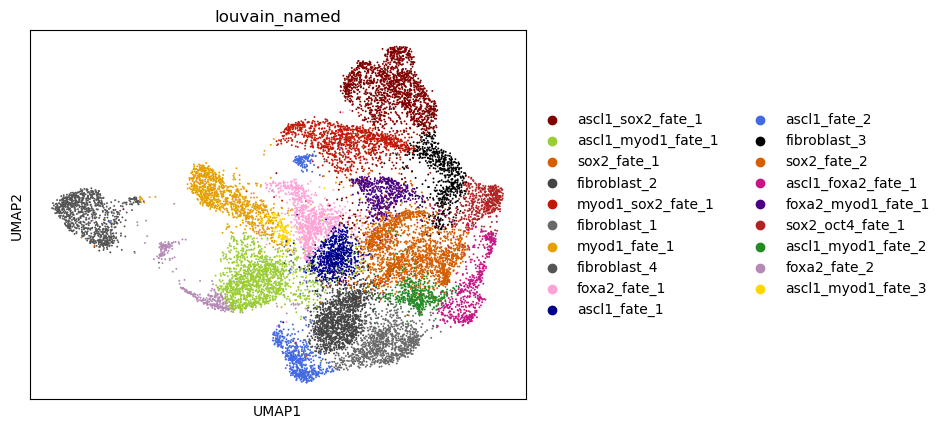

In [4]:
sc.pl.umap(
    adata_proc, color=["louvain_named"], 
)

In [5]:
condition_string = adata_proc.obs['inferred_category_real'].unique()
unique_dict = {c.split(") ")[1]:int(c.split(")")[0]) for c in condition_string}
unique_dict['control'] = 0
unique_dict['Control'] = 0
adata_proc.uns['unique_token_dict'] = unique_dict
split_key = ', '

In [6]:
adata_proc.obs['condition'] = adata_proc.obs['inferred_category_real'].apply(lambda x : x.split(") ")[1])

In [7]:
adata_proc.obs['condition']

AAACCCACAAGTGTCT-1-MUC29498          Ascl1, Foxa2
AAACCCAGTCATCCGG-1-MUC29498     Ascl1, Oct4, Sox2
AAACCCAGTCCAGCCA-1-MUC29498          Foxa2, Myod1
AAACCCATCAACCTTT-1-MUC29498                 Myod1
AAACCCATCCATTGGA-1-MUC29498    Ascl1, Myod1, Sox2
                                      ...        
TTTGTTGGTGTTTCTT-1-MUC29499     Ascl1, Oct4, Sox2
TTTGTTGTCCGGTAGC-1-MUC29499                 Ascl1
TTTGTTGTCGACGCTG-1-MUC29499           Ascl1, Sox2
TTTGTTGTCTATGTGG-1-MUC29499                 Myod1
TTTGTTGTCTCCGCAT-1-MUC29499     Myod1, Oct4, Sox2
Name: condition, Length: 15768, dtype: category
Categories (17, object): ['Ascl1', 'Foxa2', 'Myod1', 'Oct4', ..., 'Myod1, Oct4, Sox2', 'Foxa2, Oct4, Sox2', 'Ascl1, Myod1, Sox2', 'empty']

### assign root 

In [8]:
control_adata = adata_proc[adata_proc.obs.inferred_category_real == '17) empty']
control_adata.obs['cc_score'].idxmax()

root_cb = 'GTATTGGGTGTACATC-1-MUC29498'
adata_proc.uns['iroot'] = np.where(adata_proc.obs_names == root_cb )[0].item()

/home/wergillius/.conda/envs/GenDiff/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  cax = scatter(


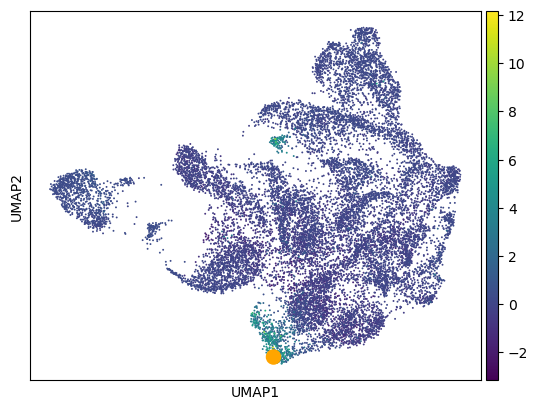

In [9]:
ax = sc.pl.umap(adata_proc, color='cc_score', show=False)
sc.pl.umap(adata_proc['GTATTGGGTGTACATC-1-MUC29498'], size=500, na_color='orange', ax=ax)

In [113]:
sc.tl.diffmap(adata_proc, n_comps=10, neighbors_key='neighbors')
sc.tl.dpt(adata_proc)

/home/wergillius/.conda/envs/GenDiff/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  cax = scatter(


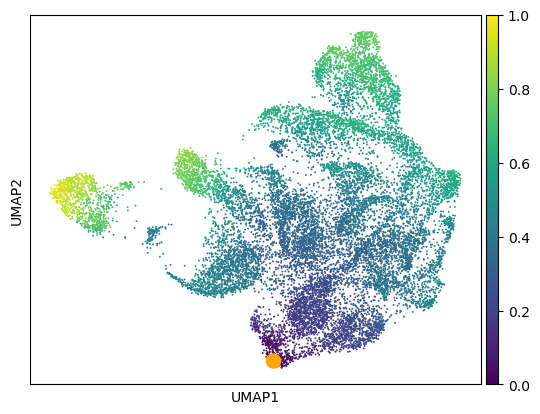

In [114]:
ax = sc.pl.umap(adata_proc, color='dpt_pseudotime', show=False)
sc.pl.umap(adata_proc['GTATTGGGTGTACATC-1-MUC29498'], size=500, na_color='orange', ax=ax)

In [10]:
from sklearn.model_selection import train_test_split

trainval_cb, test_cb = train_test_split(adata_proc.obs_names, test_size=0.1, random_state=0)
train_cb, val_cb = train_test_split(trainval_cb, test_size=0.1, random_state=0)
train_cb, val_cb = train_test_split(trainval_cb, test_size=0.1)

adata_proc.obs.loc[:,'split'] = 'test'
adata_proc.obs.loc[train_cb,'split'] = 'train'
adata_proc.obs.loc[val_cb,'split'] = 'val'

In [134]:
hvg = adata_proc.var.query('highly_variable == True').index
adata_hvg = adata_proc[:,hvg].copy()
adata_hvg

In [138]:
adata_hvg.uns['unique_token_dict']

{'Ascl1, Foxa2': 11,
 'Ascl1, Oct4, Sox2': 13,
 'Foxa2, Myod1': 12,
 'Myod1': 3,
 'Ascl1, Myod1, Sox2': 16,
 'Foxa2, Oct4, Sox2': 15,
 'Myod1, Oct4, Sox2': 14,
 'Ascl1, Sox2': 6,
 'Foxa2': 2,
 'Oct4': 4,
 'Foxa2, Sox2': 10,
 'empty': 17,
 'Ascl1': 1,
 'Sox2': 5,
 'Myod1, Sox2': 8,
 'Ascl1, Myod1': 7,
 'Oct4, Sox2': 9,
 'control': 0,
 'Control': 0}

In [8]:
adata_hvg.X = adata_hvg.X.todense()

In [3]:
adata_hvg = sc.read_h5ad(f"{data_dir}/adata_proc_May24.h5ad")

In [16]:
a = np.multiply(adata_hvg.obs['dpt_pseudotime'],200).apply(np.sqrt).astype(int)
b = np.multiply(adata_hvg.obs['dpt_pseudotime'],200).astype(int)

In [18]:
import matplotlib.pyplot as plt

In [4]:
adata_hvg.obs['discrete_time'] = np.multiply(adata_hvg.obs['dpt_pseudotime'],200).astype(int)

In [17]:
adata_hvg.write_h5ad(f"{data_dir}/adata_proc_hvg_May24.h5ad")

NameError: name 'adata_hvg' is not defined

# sample deltaX

In [22]:
from importlib import reload
import src._diffplot as dfp
from src import _configure

/home/wergillius/Project/diffuse_differentiate/script/path_n_util.py
/home/wergillius/Project/diffuse_differentiate/machine_config.json


In [23]:
import scvelo as scv

In [18]:
adata_hvg = sc.read_h5ad(f"{data_dir}/adata_proc_hvg_May24.h5ad")
adata_hvg.uns['iroot']

In [28]:
adata_hvg

AnnData object with n_obs × n_vars = 15768 × 4000
    obs: 'batch', 'time', 'Ascl1', 'Ascl1_log', 'Foxa2', 'Foxa2_log', 'Myod1', 'Myod1_log', 'Oct4', 'Oct4_log', 'Sox2', 'Sox2_log', 'DsRed', 'DsRed_log', 'AcGFP1', 'AcGFP1_log', 'EBFP2', 'EBFP2_log', 'Ascl1_endogenous_log', 'Foxa2_endogenous_log', 'Myod1_endogenous_log', 'Pou5f1', 'Pou5f1_endogenous_log', 'Sox2_endogenous_log', 'total_count_with_transgenes', 'total_count_without_transgenes', 'n_genes', 'n_counts', 'log_n_counts', 'mt_frac', 'sf', 'sf_withtransgene', 'Ascl1_norm_log', 'Foxa2_norm_log', 'Myod1_norm_log', 'Oct4_norm_log', 'Sox2_norm_log', 'DsRed_norm_log', 'AcGFP1_norm_log', 'EBFP2_norm_log', 'sf_withouttransgene', 'louvain', 'S_score', 'G2M_score', 'phase', 'louvain_named', 'louvain_lineage', 'louvain_lineage_coarse', 'cc_score', 'Ascl1_positive_gmm', 'Ascl1_positive_optim', 'Foxa2_positive_gmm', 'Foxa2_positive_optim', 'Myod1_positive_gmm', 'Myod1_positive_optim', 'Oct4_positive_gmm', 'Oct4_positive_optim', 'Sox2_positiv

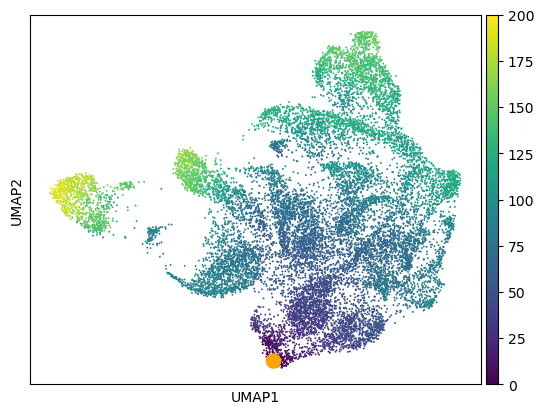

In [27]:
ax = sc.pl.umap(adata_hvg, color='discrete_time', show=False)
sc.pl.umap(adata_hvg['GTATTGGGTGTACATC-1-MUC29498'], size=500, na_color='orange', ax=ax)

In [24]:
relative_path = "configs/Collide-seq/afmos_Traversal/debug.yaml"
trav_delta_x = dfp.sample_Delta_X(relative_path,n_workers=20,
                        sampling_repeat =1)   

Sample data using dataset class Traverse_Dataset
preparing dataloaders ...
loading adata ...
Sampling ...


100%|██████████| 50/50 [00:03<00:00, 12.59it/s]


computing velocity graph (using 20/48 cores)


  0%|          | 0/15768 [00:00<?, ?cells/s]

    finished (0:02:17) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:05) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


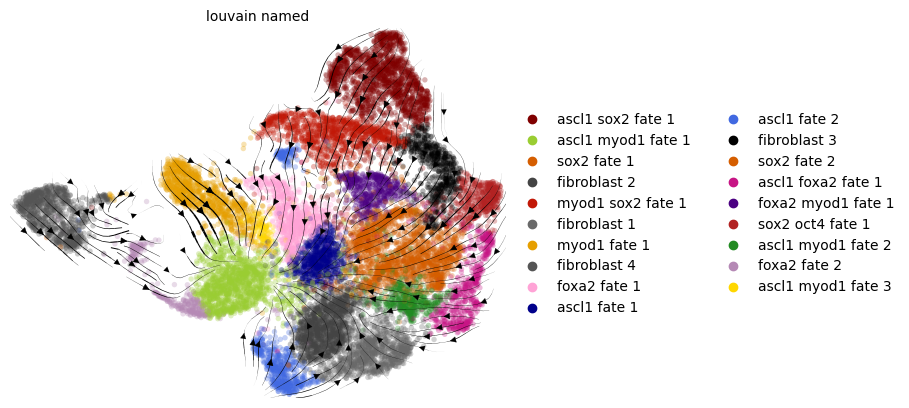

In [25]:
collide_trv_adata = dfp.compute_velocity(adata=adata_hvg, 
                    velocity_matrix=trav_delta_x,
                    n_neighbors = None, n_jobs=20)
scv.pl.velocity_embedding_stream(collide_trv_adata,
                                    color='louvain_named', 
                                    legend_loc='far right', 
                                    )

computing velocity graph (using 20/48 cores)


  0%|          | 0/15768 [00:00<?, ?cells/s]

    finished (0:02:09) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:04) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


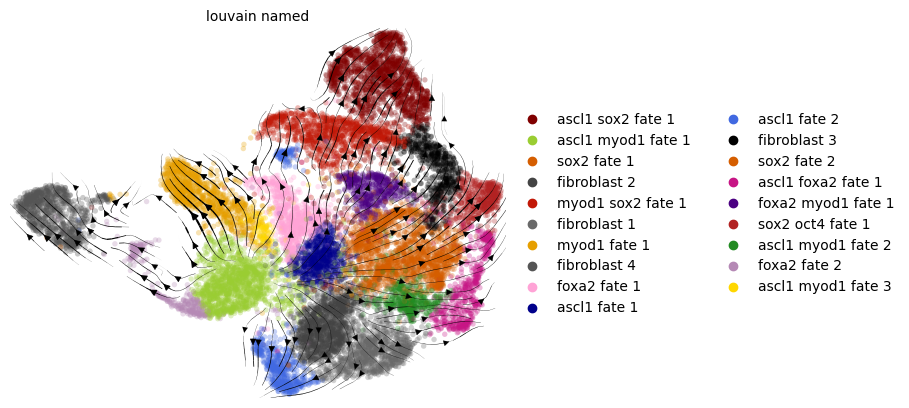

In [14]:
collide_trv_adata = dfp.compute_velocity(adata=adata_hvg, 
                    velocity_matrix=trav_delta_x*-1,
                    n_neighbors = None, n_jobs=20)
scv.pl.velocity_embedding_stream(collide_trv_adata,
                                    color='louvain_named', 
                                    legend_loc='far right', 
                                    )

## read velo merge data

In [60]:
adata_raw = sc.read_h5ad(f"{data_dir}/adata_filtered_velo_bycond_merged.h5ad")
adata_raw

AnnData object with n_obs × n_vars = 15768 × 22613
    obs: 'batch', 'time', 'Ascl1', 'Ascl1_log', 'Foxa2', 'Foxa2_log', 'Myod1', 'Myod1_log', 'Oct4', 'Oct4_log', 'Sox2', 'Sox2_log', 'DsRed', 'DsRed_log', 'AcGFP1', 'AcGFP1_log', 'EBFP2', 'EBFP2_log', 'Ascl1_endogenous_log', 'Foxa2_endogenous_log', 'Myod1_endogenous_log', 'Pou5f1', 'Pou5f1_endogenous_log', 'Sox2_endogenous_log', 'total_count_with_transgenes', 'total_count_without_transgenes', 'n_genes', 'n_counts', 'log_n_counts', 'mt_frac', 'sf', 'sf_withtransgene', 'Ascl1_norm_log', 'Foxa2_norm_log', 'Myod1_norm_log', 'Oct4_norm_log', 'Sox2_norm_log', 'DsRed_norm_log', 'AcGFP1_norm_log', 'EBFP2_norm_log', 'sf_withouttransgene', 'louvain', 'S_score', 'G2M_score', 'phase', 'louvain_named', 'louvain_lineage', 'louvain_lineage_coarse', 'cc_score', 'Ascl1_positive_gmm', 'Ascl1_positive_optim', 'Foxa2_positive_gmm', 'Foxa2_positive_optim', 'Myod1_positive_gmm', 'Myod1_positive_optim', 'Oct4_positive_gmm', 'Oct4_positive_optim', 'Sox2_positi

In [12]:
condition_string = adata_raw.obs['inferred_category_real'].unique()

In [17]:
unique_dict = {c.split(") ")[1]:int(c.split(")")[0]) for c in condition_string}
adata_raw.uns['unique_token_dict'] = unique_dict
split_key = ', '

In [24]:
import pickle

In [26]:
dir_anndata = "/home/d24h_prog5/share/Chapter_I/results/anndata/afmos/"
adata_filtered_velo_bycond = pickle.load(open(dir_anndata + "adata_filtered_velo_bycond.pickle", 'rb'))

/tmp/ipykernel_16792/2956590285.py:2: DeprecationWarning: Please use `csr_matrix` from the `scipy.sparse` namespace, the `scipy.sparse.csr` namespace is deprecated.
  adata_filtered_velo_bycond = pickle.load(open(dir_anndata + "adata_filtered_velo_bycond.pickle", 'rb'))


In [30]:
all_roots = [adata.obs['root_cells'].idxmin() for adata in adata_filtered_velo_bycond.values()]

In [54]:
adata_filtered_velo_bycond['17) empty'].obs['root_cells'].idxmin()

'GAACGTTCATTCTCCG-1-MUC29498'

In [55]:
'GAACGTTCATTCTCCG-1-MUC29498' in all_roots

True

In [35]:
adata_raw.obs['is_root'] = "False"
adata_raw.obs.loc[all_roots, 'is_root'] = "True"

/home/wergillius/.conda/envs/GenDiff/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/wergillius/.conda/envs/GenDiff/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


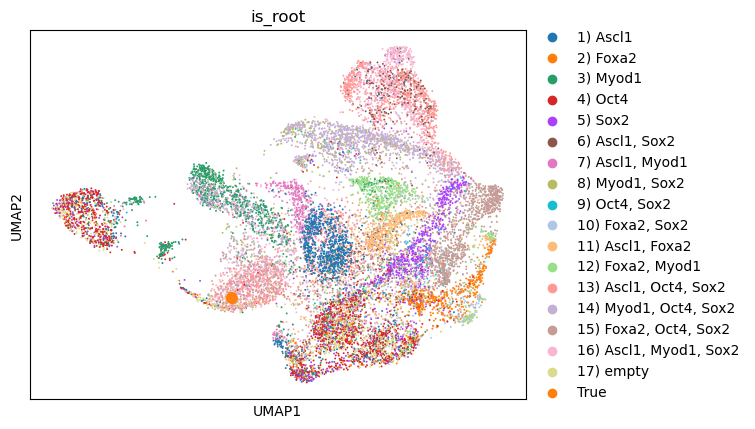

In [56]:
ax = sc.pl.umap(adata_raw, color='inferred_category_real', show=False)
# ax = fig.gca()
sc.pl.umap(adata_raw['GAACGTTCATTCTCCG-1-MUC29498'], color='is_root', size=300, ax=ax)

In [48]:
import scvelo as scv

In [50]:
sc.pp.neighbors(adata_raw, 30)

computing terminal states


ValueError: You need to run `tl.velocity_graph` first to compute cosine correlations.

In [ ]:
scv.tl.terminal_states(adata_raw)

In [45]:
adata_raw

AnnData object with n_obs × n_vars = 15768 × 22613
    obs: 'batch', 'time', 'Ascl1', 'Ascl1_log', 'Foxa2', 'Foxa2_log', 'Myod1', 'Myod1_log', 'Oct4', 'Oct4_log', 'Sox2', 'Sox2_log', 'DsRed', 'DsRed_log', 'AcGFP1', 'AcGFP1_log', 'EBFP2', 'EBFP2_log', 'Ascl1_endogenous_log', 'Foxa2_endogenous_log', 'Myod1_endogenous_log', 'Pou5f1', 'Pou5f1_endogenous_log', 'Sox2_endogenous_log', 'total_count_with_transgenes', 'total_count_without_transgenes', 'n_genes', 'n_counts', 'log_n_counts', 'mt_frac', 'sf', 'sf_withtransgene', 'Ascl1_norm_log', 'Foxa2_norm_log', 'Myod1_norm_log', 'Oct4_norm_log', 'Sox2_norm_log', 'DsRed_norm_log', 'AcGFP1_norm_log', 'EBFP2_norm_log', 'sf_withouttransgene', 'louvain', 'S_score', 'G2M_score', 'phase', 'louvain_named', 'louvain_lineage', 'louvain_lineage_coarse', 'cc_score', 'Ascl1_positive_gmm', 'Ascl1_positive_optim', 'Foxa2_positive_gmm', 'Foxa2_positive_optim', 'Myod1_positive_gmm', 'Myod1_positive_optim', 'Oct4_positive_gmm', 'Oct4_positive_optim', 'Sox2_positi

In [ ]:
# differrential analysis
# \hat{dX} = 0 ?

# braching point ?
# 

In [ ]:
# Integrated gradient